In [59]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
import seaborn as sns

# For the custom legend
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple

from my_fun import sine_wave, white_noise, fig_size, save_notebook_files

In [2]:
# Magics
%load_ext autoreload
%autoreload 2

In [3]:
# Plotting style
sns.set_theme(style='ticks', context='notebook')
style_path = os.path.expanduser('~/PycharmProjects/alexis_style.mplstyle')
plt.style.use(style_path)
%config InlineBackend.figure_format = 'svg'
# %config InlineBackend.figure_format = 'png'
# %config InlineBackend.figure_format = 'retina'
lw = mpl.rcParams['lines.linewidth']

In [4]:
# Load stimuli set
path = Path.home() / 'PycharmProjects' / 'create_sounds' / 'sounds_6.1.csv'
df = pd.read_csv(path)

# Stimuli set

In [36]:
# Compute the mean of left envelopes (EL) per row
df['EL_mean'] = df.loc[:, 'EL0':'EL10'].mean(axis=1)  # Add 'EL_mean' to the DataFrame
EL_mean_min = round(min(df.EL_mean[0:-1]), -1)  # Exclude the last value for EL_mean_min (0)
EL_mean_max = round(max(df.EL_mean))

# Compute the mean of right envelopes (ER) per row
df['ER_mean'] = df.loc[:, 'ER0':'ER10'].mean(axis=1)  # Add 'ER_mean' to the DataFram
ER_mean_min = round(min(df.ER_mean[1:]), -1)  # Exclude the first value for EL_mean_min (0)
ER_mean_max = round(max(df.ER_mean))

# Compute ILD as the difference between EL_mean and ER_mean for coloring
df['abs_ILD'] = df.ILD.abs()  # Take absolute ILD values for color grouping
unique_abs_ilds = sorted(df.abs_ILD.unique())  # Get unique absolute ILD values and assign colors
unique_ilds = sorted(df.ILD.unique())  # Get unique ILD values for labeling
unique_ilds = unique_ilds[1:-1]  # Exclude the extreme ILD values (-70 and 70) for better color distinction

cmap_colors = get_cmap('tab20c').colors
colors = {
    # -70: cmap_colors[0],  # Dark blue
    -8: cmap_colors[1],  # Medium dark blue
    -4: cmap_colors[2],  # Medium light blue
    -2: cmap_colors[3],  # Light blue
    0:  cmap_colors[19],  # Light gray
    2: cmap_colors[7],  # Dark blue
    4: cmap_colors[6],  # Medium dark blue
    8: cmap_colors[5],  # Medium light blue
    # 70: cmap_colors[4]  # Light blue
}

# Create a dictionary to map absolute ILD values to colors
# abs_ild_to_color = {abs_ild: cmap(i) for i, abs_ild in enumerate(unique_abs_ilds)}

/tmp/ipykernel_2914438/1516510497.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_colors = get_cmap('tab20c').colors


ILD: -8
ILD: -4
ILD: -2
ILD: 0
ILD: 2
ILD: 4
ILD: 8


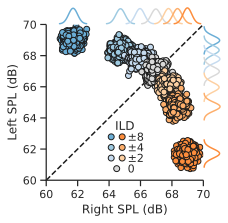

In [46]:
# Main figure and axes
figsize = fig_size(n_cols=2)
figsize = (figsize[0], figsize[0])  # Make it square
fig = plt.figure(figsize=figsize)
# plt.axis('square')

# Create grid layout to place additional x and y axes for plotting ILD distributions
gs = fig.add_gridspec(2, 2, width_ratios=(9, 1), height_ratios=(1, 9), wspace=0, hspace=0)

# Main scatter and marginal distribution axes
ax_scatter = fig.add_subplot(gs[1,0])
ax_xdist  = fig.add_subplot(gs[0,0])
ax_ydist  = fig.add_subplot(gs[1,1])

# Equity line
ax_scatter.plot(np.arange(ER_mean_min, ER_mean_max + 1),
                np.arange(ER_mean_min, ER_mean_max + 1),
                color='k', linestyle='--', zorder=0)

# Scatter
for ild in unique_ilds:
    print(f'ILD: {ild}')
    subset = df[df.ILD == ild]
    ax_scatter.scatter(subset.ER_mean, subset.EL_mean, color=colors[ild], edgecolor='k', zorder=2)

    mu_x, sigma_x = subset.ER_mean.mean(), subset.ER_mean.std()
    mu_y, sigma_y = subset.EL_mean.mean(), subset.EL_mean.std()
    # print(f'mu_x: {mu_x}, mu_y: {mu_y}')
    # print(f'sigma_x: {sigma_x}, sigma_y: {sigma_y}')

    # Normal distributions
    xx = np.linspace(mu_x - 3*sigma_x, mu_x + 3*sigma_x, 100)
    yy = np.linspace(mu_y - 3*sigma_y, mu_y + 3*sigma_y, 100)
    x_pdf = norm.pdf(xx, mu_x, sigma_x)
    y_pdf = norm.pdf(yy, mu_y, sigma_y)

    ax_xdist.plot(xx, x_pdf, color=colors[ild])
    ax_ydist.plot(y_pdf, yy, color=colors[ild])

# Set ticks
ticks = np.arange(ER_mean_min, ER_mean_max + 1, 2)
ax_scatter.set_xticks(ticks)
ax_scatter.set_yticks(ticks)

# Limits
ax_scatter.set_xlim(EL_mean_min, EL_mean_max)
ax_scatter.set_ylim(ER_mean_min, ER_mean_max)
ax_xdist.set_xlim(ax_scatter.get_xlim())
ax_ydist.set_ylim(ax_scatter.get_ylim())

# Labels
ax_scatter.set_xlabel('Right SPL (dB)')
ax_scatter.set_ylabel('Left SPL (dB)')

# Despine
sns.despine(ax=ax_scatter)
sns.despine(ax=ax_xdist, top=True, right=True, left=True, bottom=True)
sns.despine(ax=ax_ydist, top=True, right=True, left=True, bottom=True)

# Hide tick labels on marginal axes only
for ax in [ax_xdist, ax_ydist]:
    ax.set_xticks([])
    ax.set_yticks([])

# Add title
# fig.suptitle('Stimuli set')


# Custom legend

# Create legend handles as tuples (negative dot, positive dot)
legend_handles = [
    # (
    #     Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[-70], markeredgecolor='k'),
    #     Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[70], markeredgecolor='k')
    # ),
    (
        Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[-8], markeredgecolor='k'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[8], markeredgecolor='k')
    ),
    (
        Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[-4], markeredgecolor='k'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[4], markeredgecolor='k')
    ),
    (
        Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[-2], markeredgecolor='k'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[2], markeredgecolor='k')
    ),
]

# Add single handle for 0 (gray dot)
zero_handle = Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[0], markeredgecolor='k')

# Add zero handle at the end of handles list
legend_handles.append(zero_handle)

# Labels
labels = [
    # '±70',
    '±8', '±4', '±2', '0']

ax_scatter.legend(
    loc='lower center',
    handles=legend_handles,
    labels=labels,
    handler_map={tuple: HandlerTuple(ndivide=None)},
    title='ILD',
    ncol=1,
    handletextpad=0,
    borderpad=0,
    labelspacing=0,
    frameon=False,
)

# Plot samples from example distribution

[]

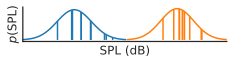

In [54]:
# Slice df ild
ild = 2   # So the distributions are closer
df_sub = df[df.ILD == ild]

# Get the mean of columns EL_mean and ER_mean
mu_EL = df_sub.EL_mean.mean()
mu_ER = df_sub.ER_mean.mean()

# Get the std of columns EL_mean and ER_mean
sigma_EL = df_sub.EL_mean.std()
sigma_ER = df_sub.ER_mean.std()

# Create figure with 2 stacked subplots
figsize = fig_size(n_cols=2)
figsize = (figsize[0], figsize[1]*(1/3))  # Make it two-thirds tall
# fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=figsize, sharex=True, constrained_layout=True)
fig, ax = plt.subplots(1, 1, figsize=figsize, sharex=True, constrained_layout=True)

# Normal PDFs
x_ER = np.linspace(mu_ER - 3*sigma_ER, mu_ER + 3*sigma_ER)
x_EL = np.linspace(mu_EL - 3*sigma_EL, mu_EL + 3*sigma_EL)
pdf_ER = norm.pdf(x_ER, mu_ER, sigma_ER)
pdf_EL = norm.pdf(x_EL, mu_EL, sigma_EL)

# Draw 10 random samples
np.random.seed(0)
samples_EL = np.random.normal(mu_EL, sigma_EL, 10)
samples_ER = np.random.normal(mu_ER, sigma_ER, 10)

# Plot PDFs
ax.plot(x_ER, pdf_ER, color='tab:orange')
ax.plot(x_EL, pdf_EL, color='tab:blue')

# Stem plots for samples
stems_right = ax.stem(samples_ER, norm.pdf(samples_ER, mu_ER, sigma_ER), linefmt='k-', markerfmt='', basefmt='none')
stems_left = ax.stem(samples_EL, norm.pdf(samples_EL, mu_EL, sigma_EL), linefmt='k-', markerfmt='', basefmt='none')
plt.setp(stems_right.markerline, color='tab:orange')
plt.setp(stems_right.stemlines, color='tab:orange')
plt.setp(stems_left.markerline, color='tab:blue')
plt.setp(stems_left.stemlines, color='tab:blue')

# Labels and titles
ax.set_xlim(x_EL[0], x_ER[-1])
ax.set_xlabel('SPL (dB)')
ax.set_ylabel(r'$ \it{p}$(SPL)')
sns.despine()

# Remove tick
ax.set_xticks([])
ax.set_yticks([])

# Plot samples as stairs

[]

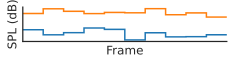

In [56]:
# Create figure with 2 stacked subplots
figsize = fig_size(n_cols=2)
# figsize = (figsize[0], figsize[0])  # Make it square
figsize = (figsize[0], figsize[1]*(1/3))  # Make it half tall
# fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=figsize, sharex=True, sharey=True, constrained_layout=True)
fig, ax = plt.subplots(1, 1, figsize=figsize, sharex=True, sharey=True, constrained_layout=True)

# Plot the 10 samples as stairs
x_indices = np.arange(10 + 1)
ax.stairs(samples_ER, np.arange(len(samples_ER)+1), color='tab:orange', lw=lw, baseline=None)
ax.stairs(samples_EL, np.arange(len(samples_EL)+1), color='tab:blue', lw=lw, baseline=None)

ax.set_xlim(x_indices[0], x_indices[-1])
ax.set_xlabel('Frame')
ax.set_ylabel('SPL (dB)')
sns.despine()
ax.set_xticks([])
ax.set_yticks([])

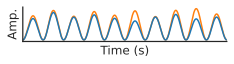

In [61]:
# Slice df ild (greater non max ILD for better illustration)
ild = 2
df_sub = df[df.ILD == ild]

# Randomly pick one row (sound) from df_sub
row = df_sub.sample(n=1, random_state=0).iloc[0]

# Extract 10 frame values for left and right
samples_EL = row[[f'EL{i+1}' for i in range(10)]].values
samples_ER = row[[f'ER{i+1}' for i in range(10)]].values
# print(samples_EL)
# print(samples_ER)

# Convert your dB samples to linear amplitudes
samples_EL = 10 ** (samples_EL / 20)
samples_ER = 10 ** (samples_ER / 20)

# Generate sine wave
dur = 1          # Duration in seconds
fs = 44100       # Sampling frequency
n_frames = 10    # Number of frames (samples)
amp = 0.5        # Amplitude
cutoff = [2000, 20000]
fn = 10000
normalize = True

x, sine = sine_wave(length=dur, fs=fs, cycles=n_frames, amp=amp, phase=-np.pi/2, v_shift=0.5, plot=False)

# Create envelope from 10 samples
counts = np.full(n_frames, len(x) // n_frames)
counts[:len(x) % n_frames] += 1
envelope_EL = np.repeat(samples_EL, counts)
envelope_ER = np.repeat(samples_ER, counts)

# Modulated signals
modulated_EL = envelope_EL * sine * amp
modulated_ER = envelope_ER * sine * amp

# Create figure with 2 stacked subplots
figsize = fig_size(n_cols=2)
figsize = (figsize[0], figsize[1]*(1/3))  # Make it two-thirds tall
# fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=figsize, sharex=True, sharey=True, constrained_layout=True)
fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)

ax.plot(x, modulated_ER, color='tab:orange')
ax.plot(x, modulated_EL, color='tab:blue')

ax.set_xlim(x[0], x[-1])
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amp.')
ax.set_xticks([])
ax.set_yticks([])
sns.despine()

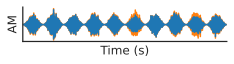

In [63]:
# Slice df ild (greater non max ILD for better illustration)
ild = 2
df_sub = df[df.ILD == ild]

# Randomly pick one row (sound) from df_sub
row = df_sub.sample(n=1, random_state=0).iloc[0]

# Extract 10 frame values for left and right
samples_EL = row[[f'EL{i+1}' for i in range(10)]].values
samples_ER = row[[f'ER{i+1}' for i in range(10)]].values
# print(samples_EL)
# print(samples_ER)

# Convert your dB samples to linear amplitudes
samples_EL = 10 ** (samples_EL / 20)
samples_ER = 10 ** (samples_ER / 20)

# Generate sine wave
dur = 1          # Duration in seconds
fs = 44100       # Sampling frequency
n_frames = 10    # Number of frames (samples)
amp = 0.5        # Amplitude
cutoff = [2000, 20000]
fn = 10000
normalize = True

x, sine = sine_wave(length=dur, fs=fs, cycles=n_frames, amp=amp, phase=-np.pi/2, v_shift=0.5, plot=False)
noise = white_noise(fs=fs, cutoff=cutoff, amp=amp, dur=dur, fn=fn, normalize=normalize)

# Create envelope from 10 samples
counts = np.full(n_frames, len(x) // n_frames)
counts[:len(x) % n_frames] += 1
envelope_EL = np.repeat(samples_EL, counts)
envelope_ER = np.repeat(samples_ER, counts)

# Modulated signals
modulated_EL = envelope_EL * sine * amp * noise
modulated_ER = envelope_ER * sine * amp * noise

# Create figure with 2 stacked subplots
figsize = fig_size(n_cols=2)
figsize = (figsize[0], figsize[1]*(1/3))  # Make it two-thirds tall
# fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=figsize, sharex=True, sharey=True, constrained_layout=True)
fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)

ax.plot(x, modulated_ER, color='tab:orange')
ax.plot(x, modulated_EL, color='tab:blue')

ax.set_xlim(x[0], x[-1])
ax.set_xlabel('Time (s)')
ax.set_ylabel('AM')
ax.set_xticks([])
ax.set_yticks([])
sns.despine()

# Save all notebook's outputs

In [64]:
# # Whole notebook outputs (no input or prompt, only Markdown and figures)
# # As HTML
# !jupyter nbconvert notebook.ipynb --to html --no-input --no-prompt
# # As PDF
# !jupyter nbconvert notebook.ipynb --to pdf --no-input --no-prompt
#
# Export all figures
save_notebook_files(notebook_path='notebook.ipynb')

Saved 5 images to notebook_files/
